In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [54]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style("whitegrid")

df = pd.read_csv("german.csv", sep=";")
df.head()

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,Guarantors,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,1,1,2


In [55]:
df.shape

(1000, 21)

In [56]:
df.columns

Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='object')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Creditability                      1000 non-null   int64
 1   Account_Balance                    1000 non-null   int64
 2   Duration_of_Credit_monthly         1000 non-null   int64
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64
 4   Purpose                            1000 non-null   int64
 5   Credit_Amount                      1000 non-null   int64
 6   Value_Savings_Stocks               1000 non-null   int64
 7   Length_of_current_employment       1000 non-null   int64
 8   Instalment_per_cent                1000 non-null   int64
 9   Sex_Marital_Status                 1000 non-null   int64
 10  Guarantors                         1000 non-null   int64
 11  Duration_in_Current_address        1000 non-null   int64
 12  Most_valuable_availab

In [58]:
df.describe()

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,Guarantors,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,1.145000,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,0.477706,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,1.000000,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,1.000000,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,1.000000,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,3.000000,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


In [59]:
df["Creditability"].value_counts()

Creditability
1    700
0    300
Name: count, dtype: int64

# Exploratory Data Analysis 

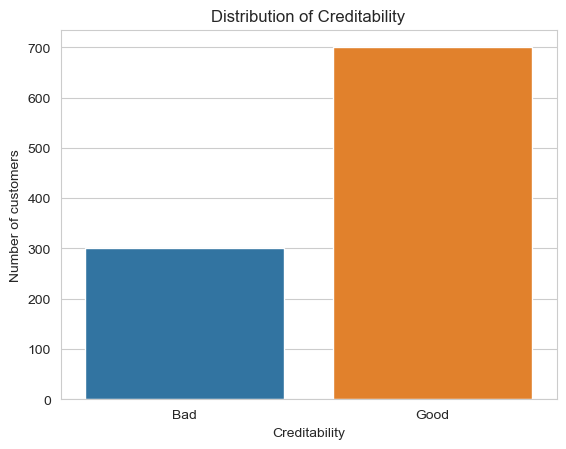

In [60]:
sns.set_style("whitegrid")

tt = sns.countplot(x = "Creditability", data = df)
tt.set_xticklabels(["Bad", "Good"])
plt.title("Distribution of Creditability")
plt.xlabel("Creditability")
plt.ylabel("Number of customers")

plt.show()

In [61]:
df.isnull().sum()

Creditability                        0
Account_Balance                      0
Duration_of_Credit_monthly           0
Payment_Status_of_Previous_Credit    0
Purpose                              0
Credit_Amount                        0
Value_Savings_Stocks                 0
Length_of_current_employment         0
Instalment_per_cent                  0
Sex_Marital_Status                   0
Guarantors                           0
Duration_in_Current_address          0
Most_valuable_available_asset        0
Age_years                            0
Concurrent_Credits                   0
Type_of_apartment                    0
No_of_Credits_at_this_Bank           0
Occupation                           0
No_of_dependents                     0
Telephone                            0
Foreign_Worker                       0
dtype: int64

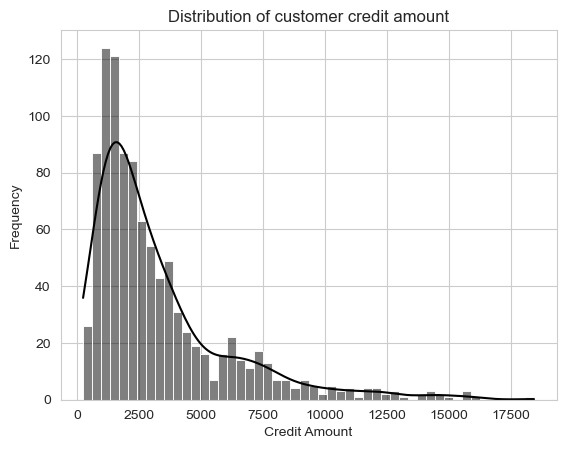

In [62]:
sns.histplot(df["Credit_Amount"],color= "Black" ,bins = 50, kde=True)
plt.title("Distribution of customer credit amount")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.show()

##### The graph of credit amount distribution shows that many customers borrow small amounts around R2000 while a few people borrow large amounts up to R15000. The data is positively skewed.

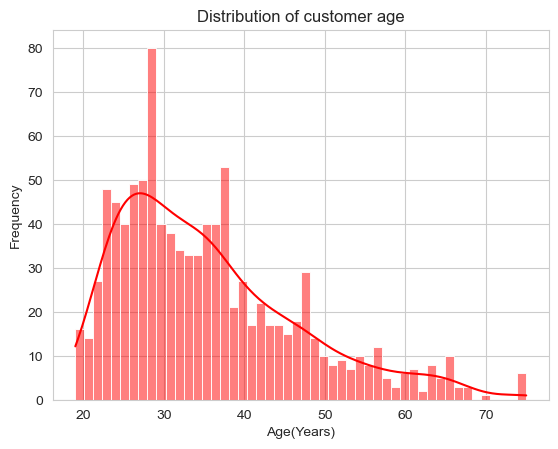

In [63]:
sns.histplot(df["Age_years"],color= "Red" ,bins = 50, kde=True)
plt.title("Distribution of customer age")
plt.xlabel("Age(Years)")
plt.ylabel("Frequency")
plt.show()

##### The age distribution indicates that most of the people getting loans are between 20 and 30 years old. A few take loans after these years but the data is positively skewed and has a few outliers after 70 years old.

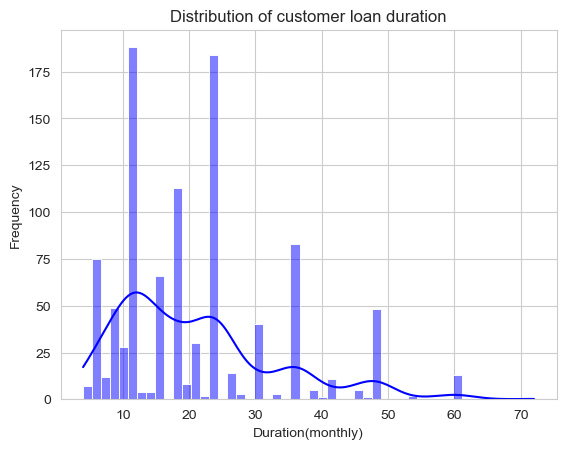

In [64]:
sns.histplot(df["Duration_of_Credit_monthly"],color= "Blue" ,bins = 50, kde=True)
plt.title("Distribution of customer loan duration")
plt.xlabel("Duration(monthly)")
plt.ylabel("Frequency")
plt.show()

##### The durations of the loans differs with a distribution that is not easily modeled. This is because the duration is dependent on the amount of the loan and the payroll of the client.

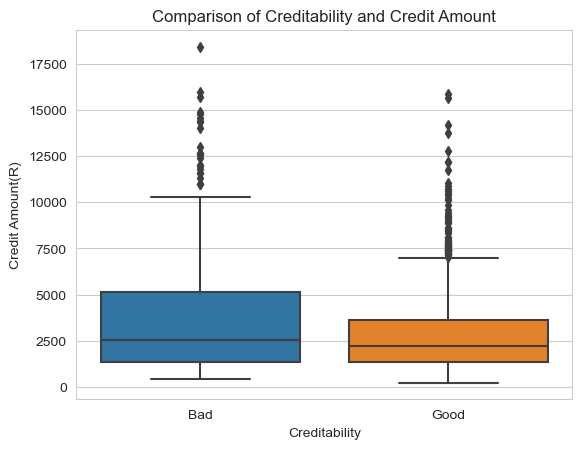

In [65]:
yy = sns.boxplot(x = "Creditability", y = "Credit_Amount", data = df)
yy.set_xticklabels(["Bad", "Good"])
plt.title("Comparison of Creditability and Credit Amount")
plt.ylabel("Credit Amount(R)")
plt.xlabel("Creditability")
plt.show()

##### It seems that clients with bad credit lend more money than those with good credit. The box and whiskers of the two credit risks are positively skewed.

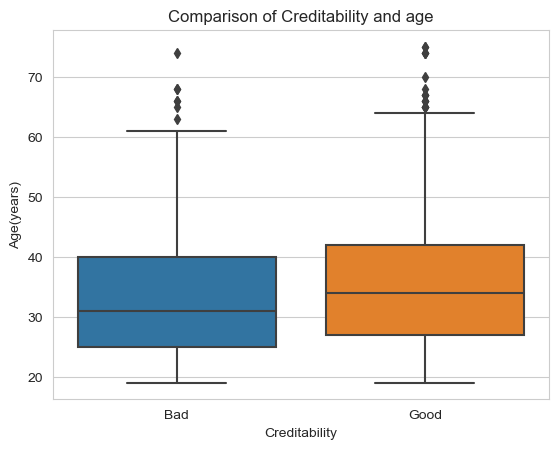

In [66]:
aa = sns.boxplot(x = "Creditability", y = "Age_years", data = df)
aa.set_xticklabels(["Bad", "Good"])
plt.title("Comparison of Creditability and age")
plt.ylabel("Age(years)")
plt.xlabel("Creditability")
plt.show()

##### The age of the clients with bad and good credit risk is fairly close but the quantiles of the clients with good cledit are just slightly higher.

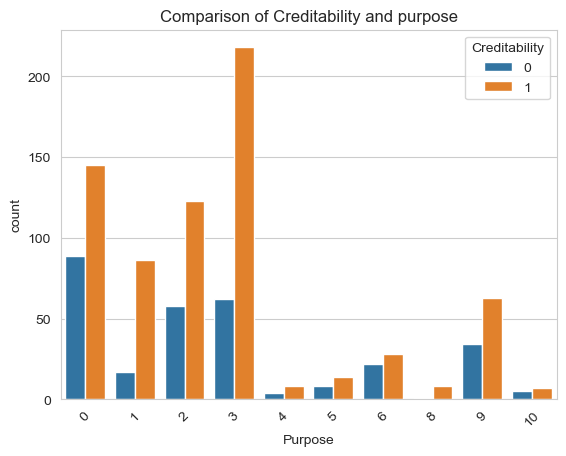

In [67]:
lc = sns.countplot(x = "Purpose", hue = "Creditability", data = df)
plt.xticks(rotation = 45)
plt.title("Comparison of Creditability and purpose")
plt.show()

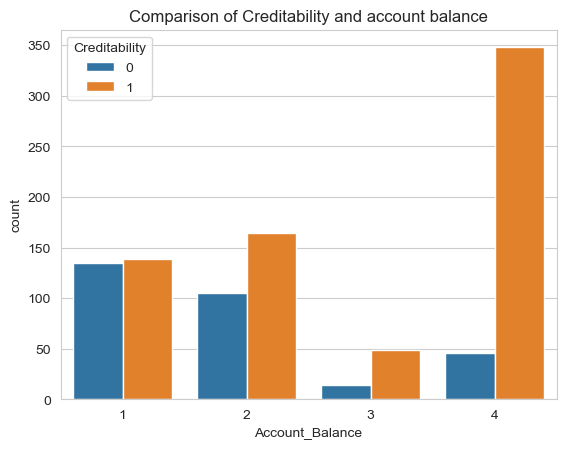

In [68]:
lc = sns.countplot(x = "Account_Balance", hue = "Creditability", data = df)
plt.title("Comparison of Creditability and account balance")
plt.show()

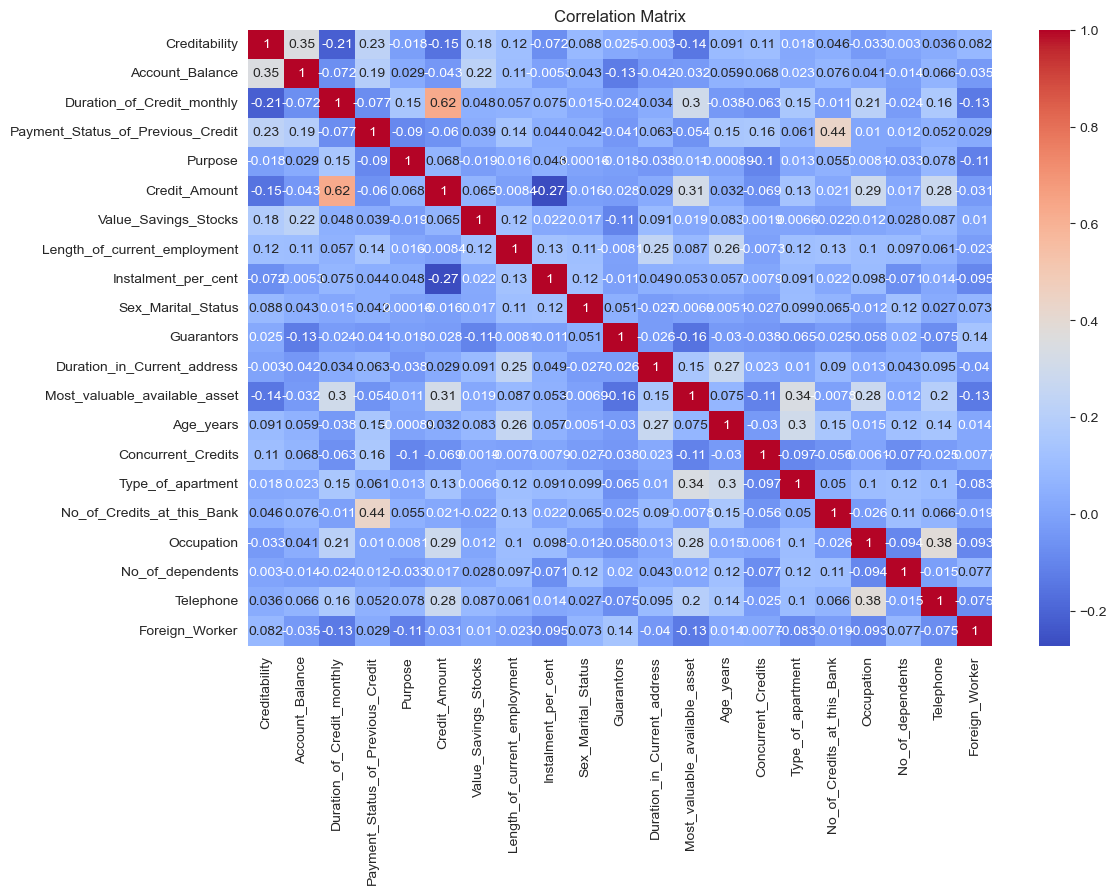

In [69]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Data Preprocessing

In [70]:
#We want to predict creditability
#We let the x variables be all the know information of the client and drop creditability
# X is our input variables
# Y is our output variable (creditability) and is what we want to predict

X = df.drop("Creditability", axis = 1) 
Y = df["Creditability"]

In [71]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

# Creating Models

Logistic Regression Model

In [76]:
LR_model = LogisticRegression(max_iter = 1000)
LR_model.fit(X_train, Y_train)
Y_pred = LR_model.predict(X_test)

In [77]:
print("Accuracy:",accuracy_score(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.735
[[ 21  41]
 [ 12 126]]
              precision    recall  f1-score   support

           0       0.64      0.34      0.44        62
           1       0.75      0.91      0.83       138

    accuracy                           0.73       200
   macro avg       0.70      0.63      0.63       200
weighted avg       0.72      0.73      0.71       200



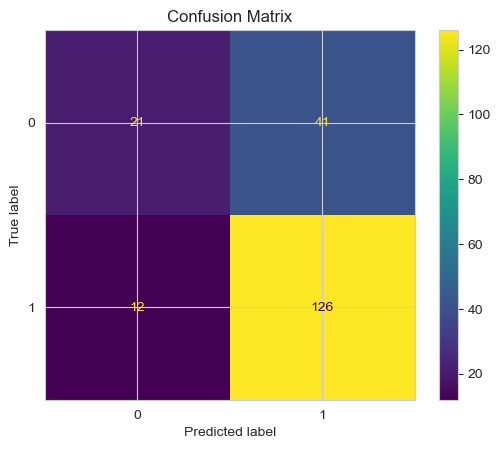

In [78]:
ConfusionMatrixDisplay.from_estimator(LR_model, X_test, Y_test)
plt.title("Confusion Matrix")
plt.show()

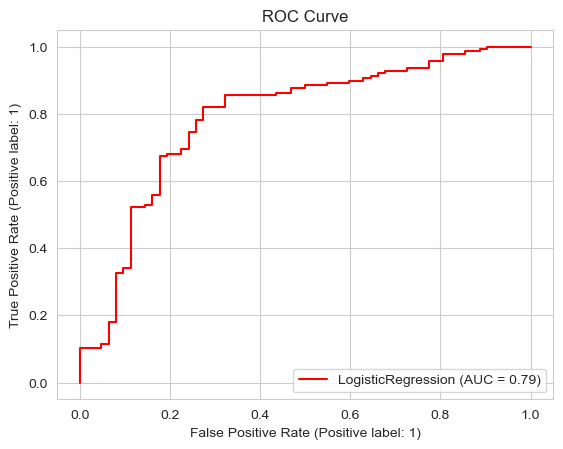

In [79]:
RocCurveDisplay.from_estimator(LR_model, X_test, Y_test, color = "Red")
plt.title("ROC Curve")
plt.show()

Random Forest Classifier Model

In [85]:
RF_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
RF_model.fit(X_train, Y_train)
RF_predictions = RF_model.predict(X_test)
RF_prob = RF_model.predict_proba(X_test)[:,1]

In [86]:
print("Accuracy", accuracy_score(Y_test, RF_predictions))
print("AUC:", roc_auc_score(Y_test, RF_prob))

Accuracy 0.76
AUC: 0.7632655446470314


## Model Comparison

#### Logistic Regression
###### Accuracy = 0.735
###### AUC = 0.79
    

#### Random Forest
###### Accuracy = 0.76
###### AUC = 0.763

Random Forest is more complex but the Logistic Regression is better for the dataset used in the project.

# Feature Importance

In [92]:
FI = pd.DataFrame({"Feature": X_train.columns, "Coefficient":LR_model.coef_[0]})
FI = FI.sort_values(by = "Coefficient", ascending = False)
FI

,Feature,Coefficient
0,Account_Balance,0.492557
2,Payment_Status_of_Previous_Credit,0.388100
18,Telephone,0.300145
5,Value_Savings_Stocks,0.266060
8,Sex_Marital_Status,0.242604
14,Type_of_apartment,0.173144
6,Length_of_current_employment,0.132081
9,Guarantors,0.090913
12,Age_years,0.006798
13,Concurrent_Credits,0.003744


$+$ coefficient increases the likelihood of good credit\
$-$ coefficient increases the likelihood of bad credit

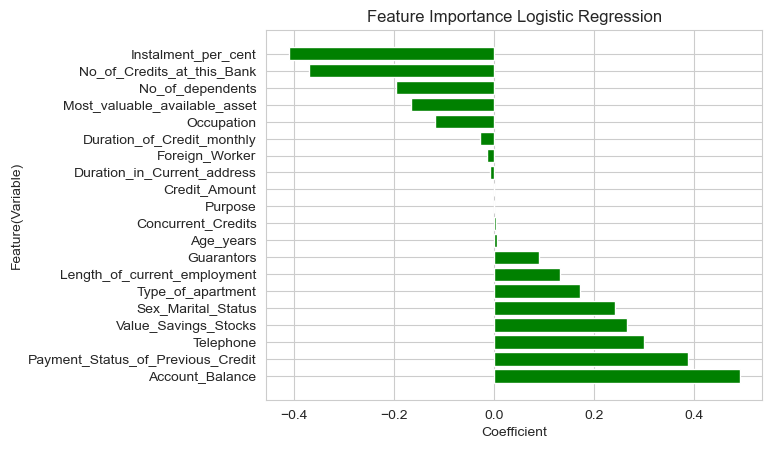

In [103]:
plt.barh(FI["Feature"], FI["Coefficient"], color = "Green")
plt.title("Feature Importance Logistic Regression")
plt.ylabel("Feature(Variable)")
plt.xlabel("Coefficient")
plt.show()

#### Logistic Regression model shows that the features that influence good credit the most are Account Balance and Previous Payment Credit status while the features that influence bad credit the most are Installment Percentage and Number of Credits at the Bank. Financial history plays an important role in finding credit risk.